# 🎯 EDA 02 — Tiros y modelo de goles esperados (xG)

**Fútbol Analytics — Copa del Mundo 2022**

Análisis profundo de la tabla `shots`: dónde y cómo se generan los tiros, qué factores explican la conversión, y comparación de nuestro modelo de xG contra el xG oficial de StatsBomb.

## 0. Setup

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resolver la raíz del proyecto (el notebook vive en notebooks/)
candidates = [Path.cwd(), Path.cwd().parent]
ROOT = next((p for p in candidates if (p / "outputs" / "futbol.db").exists()), Path.cwd())
DB = ROOT / "outputs" / "futbol.db"
EXPORTS = ROOT / "outputs" / "exports"

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13

conn = sqlite3.connect(DB)
print("Base:", DB)
print("Tablas:", pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn
)["name"].tolist())


Base: C:\Users\lauti\Documents\Proyectos\futbol-analytics\outputs\futbol.db
Tablas: ['events', 'lineups', 'matches', 'players', 'shots', 'teams']


In [2]:
shots = pd.read_sql_query("SELECT * FROM shots", conn)
# Tiros en juego (sin penales ni tandas) para el análisis de conversión
in_play = shots[(shots["period"] < 5) & (shots["is_penalty"] == 0)].copy()
print(f"Tiros totales: {len(shots)} | en juego (sin penales): {len(in_play)}")
print(f"Tasa de conversión en juego: {in_play['is_goal'].mean():.3f}")

Tiros totales: 1494 | en juego (sin penales): 1430
Tasa de conversión en juego: 0.106


## 1. Desenlaces y tipos de tiro

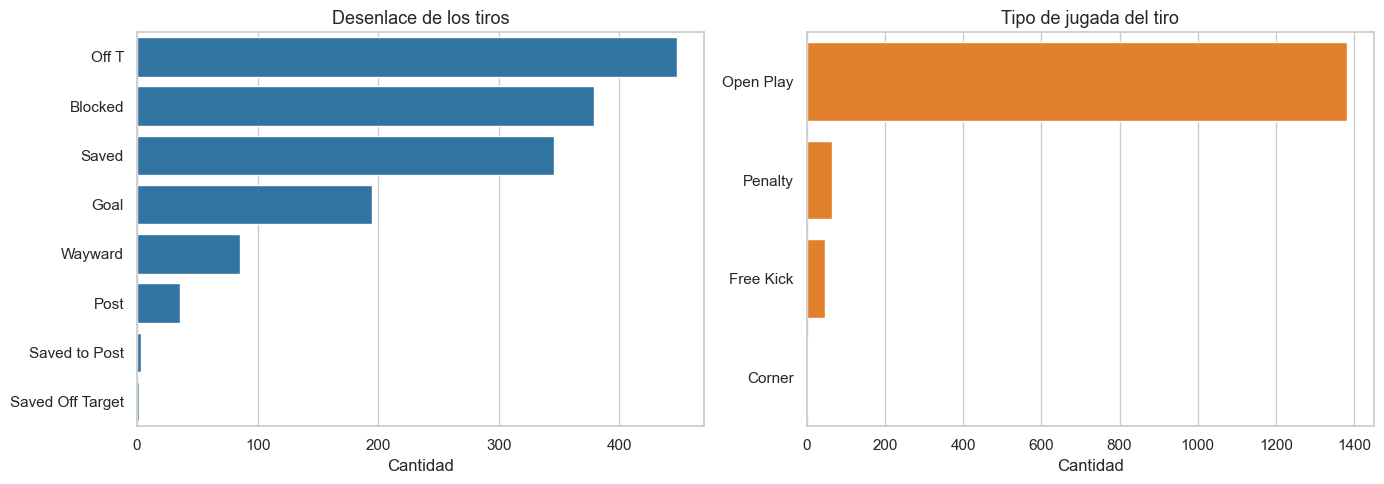

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = shots["outcome"].value_counts().index
sns.countplot(data=shots, y="outcome", order=order, ax=axes[0], color="#1f77b4")
axes[0].set_title("Desenlace de los tiros"); axes[0].set_xlabel("Cantidad"); axes[0].set_ylabel("")

sns.countplot(data=shots, y="shot_type",
              order=shots["shot_type"].value_counts().index, ax=axes[1], color="#ff7f0e")
axes[1].set_title("Tipo de jugada del tiro"); axes[1].set_xlabel("Cantidad"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

## 2. Mapa de tiros

Ubicación de los tiros en la mitad de ataque (la cancha es 120×80; el arco está en x=120). En rojo, los goles.

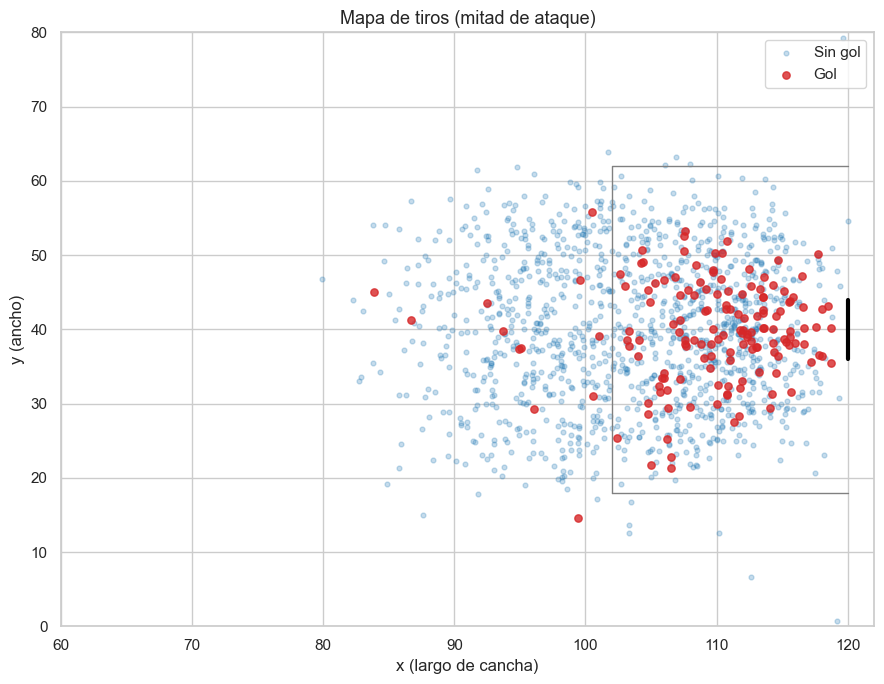

In [4]:
fig, ax = plt.subplots(figsize=(9, 7))
no_goal = in_play[in_play["is_goal"] == 0]
goal = in_play[in_play["is_goal"] == 1]
ax.scatter(no_goal["location_x"], no_goal["location_y"], s=12, alpha=0.25,
           color="#1f77b4", label="Sin gol")
ax.scatter(goal["location_x"], goal["location_y"], s=28, alpha=0.8,
           color="#d62728", label="Gol")
# Dibujar arco y área aproximados
ax.plot([120, 120], [36, 44], color="black", lw=3)             # arco
ax.plot([102, 102, 120], [18, 62, 62], color="gray", lw=1)     # borde área (parcial)
ax.plot([102, 120], [18, 18], color="gray", lw=1)
ax.set_xlim(60, 122); ax.set_ylim(0, 80)
ax.set_title("Mapa de tiros (mitad de ataque)")
ax.set_xlabel("x (largo de cancha)"); ax.set_ylabel("y (ancho)")
ax.legend(); plt.tight_layout(); plt.show()

## 3. ¿Qué explica la conversión?

Tasa de gol según distancia, parte del cuerpo y presión.

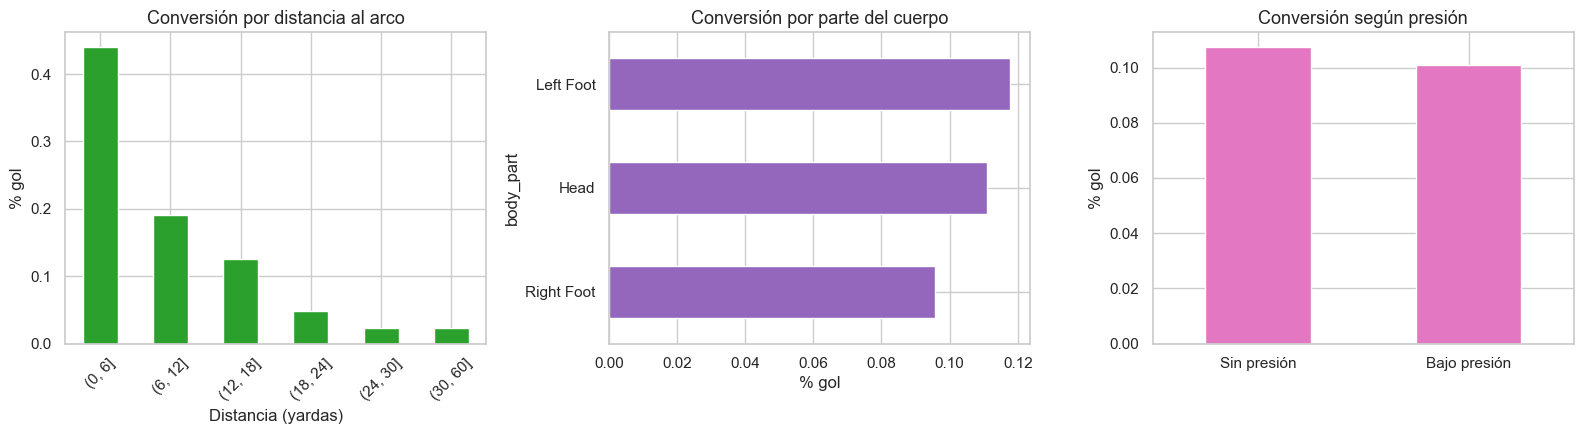

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Conversión por bins de distancia
in_play["dist_bin"] = pd.cut(in_play["distance"], bins=[0,6,12,18,24,30,60])
conv = in_play.groupby("dist_bin", observed=True)["is_goal"].mean()
conv.plot(kind="bar", ax=axes[0], color="#2ca02c")
axes[0].set_title("Conversión por distancia al arco")
axes[0].set_xlabel("Distancia (yardas)"); axes[0].set_ylabel("% gol")
axes[0].tick_params(axis="x", rotation=45)

# Conversión por parte del cuerpo
bp = in_play.groupby("body_part")["is_goal"].agg(["mean", "count"])
bp = bp[bp["count"] >= 20].sort_values("mean")
bp["mean"].plot(kind="barh", ax=axes[1], color="#9467bd")
axes[1].set_title("Conversión por parte del cuerpo"); axes[1].set_xlabel("% gol")

# Conversión bajo presión
pr = in_play.groupby("under_pressure")["is_goal"].mean()
pr.index = ["Sin presión", "Bajo presión"]
pr.plot(kind="bar", ax=axes[2], color="#e377c2")
axes[2].set_title("Conversión según presión"); axes[2].set_ylabel("% gol")
axes[2].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## 4. Geometría del tiro vs probabilidad de gol

Las dos features clave del modelo: distancia y ángulo al arco.

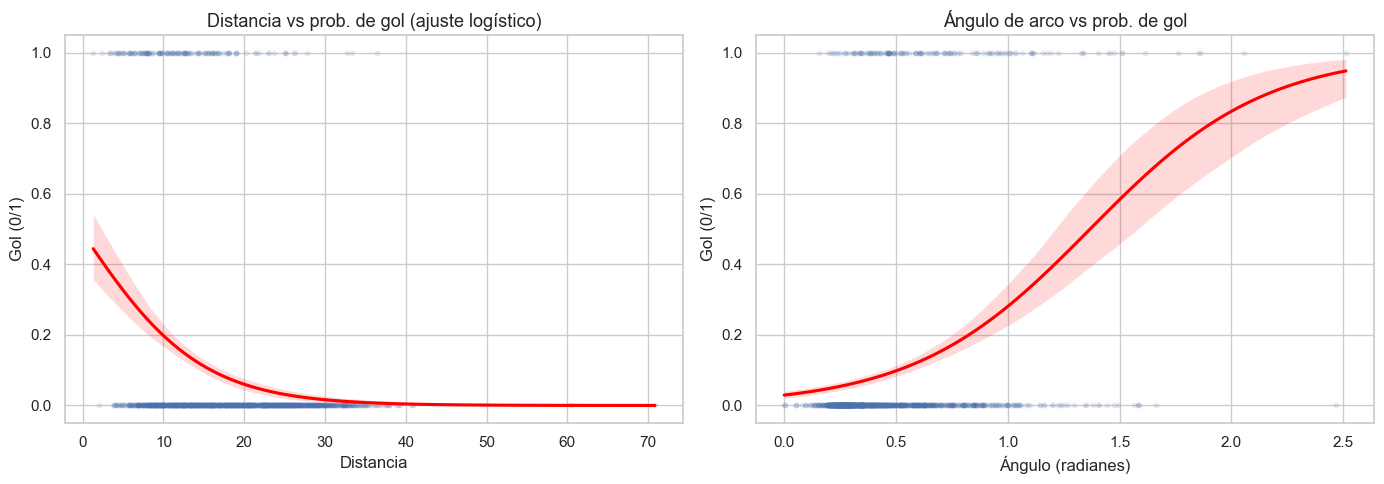

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.regplot(data=in_play, x="distance", y="is_goal", logistic=True,
            scatter_kws={"alpha": 0.1, "s": 10}, line_kws={"color": "red"}, ax=axes[0])
axes[0].set_title("Distancia vs prob. de gol (ajuste logístico)")
axes[0].set_xlabel("Distancia"); axes[0].set_ylabel("Gol (0/1)")

sns.regplot(data=in_play, x="angle", y="is_goal", logistic=True,
            scatter_kws={"alpha": 0.1, "s": 10}, line_kws={"color": "red"}, ax=axes[1])
axes[1].set_title("Ángulo de arco vs prob. de gol")
axes[1].set_xlabel("Ángulo (radianes)"); axes[1].set_ylabel("Gol (0/1)")
plt.tight_layout(); plt.show()

## 5. Nuestro modelo de xG vs StatsBomb

Comparación del xG predicho por nuestro modelo (logístico) contra el xG oficial de StatsBomb. Cargamos `xg_predicciones.csv`.

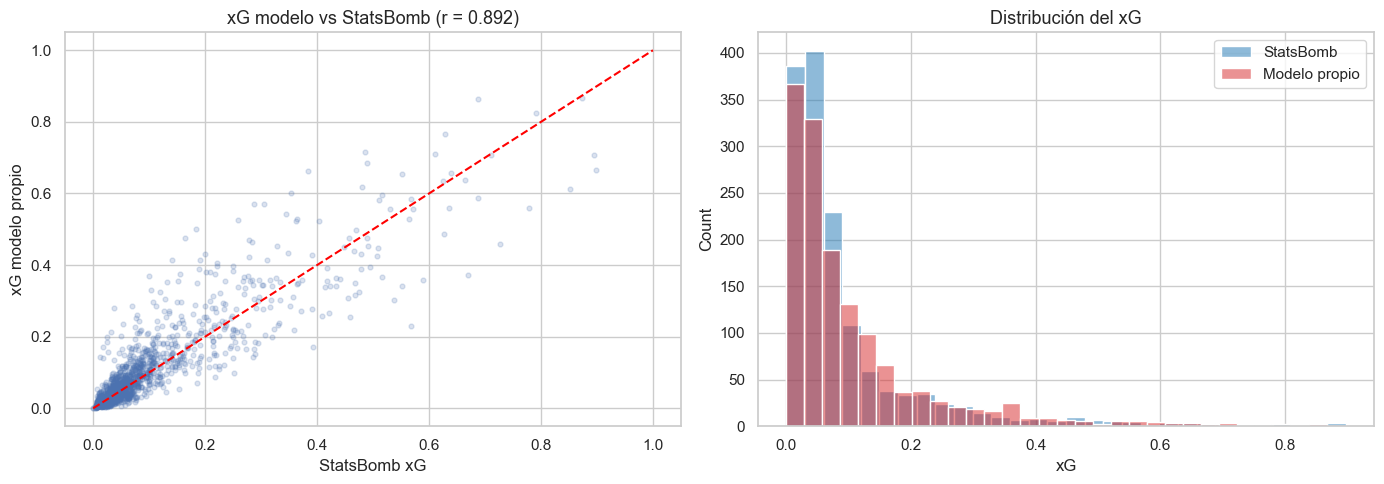

Correlación de Pearson modelo vs StatsBomb: 0.8920


In [7]:
pred = pd.read_csv(EXPORTS / "xg_predicciones.csv")
m = pred.dropna(subset=["predicted_xg", "statsbomb_xg"])
m = m[m["shot_type"] != "Penalty"]  # comparamos tiros en juego
r = np.corrcoef(m["predicted_xg"], m["statsbomb_xg"])[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(m["statsbomb_xg"], m["predicted_xg"], alpha=0.2, s=12)
axes[0].plot([0, 1], [0, 1], ls="--", color="red")
axes[0].set_title(f"xG modelo vs StatsBomb (r = {r:.3f})")
axes[0].set_xlabel("StatsBomb xG"); axes[0].set_ylabel("xG modelo propio")

sns.histplot(m["statsbomb_xg"], color="#1f77b4", label="StatsBomb", alpha=0.5,
             bins=30, ax=axes[1])
sns.histplot(m["predicted_xg"], color="#d62728", label="Modelo propio", alpha=0.5,
             bins=30, ax=axes[1])
axes[1].set_title("Distribución del xG"); axes[1].set_xlabel("xG"); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"Correlación de Pearson modelo vs StatsBomb: {r:.4f}")

## 6. Conclusiones del EDA de tiros

- La mayoría de los tiros se concentran en el área; los goles, aún más cerca y centrados.
- La conversión cae fuerte con la distancia y sube con el ángulo de arco: justifican ser las features centrales del modelo.
- Los cabezazos y los tiros bajo presión convierten menos.
- Nuestro xG correlaciona ~0.89 con el de StatsBomb usando solo features públicas: el modelo es sólido y defendible.

In [8]:
conn.close()